# 05 — The AI Tools Landscape

## Question

What is inside the `ai-tools-index`, and how does it relate to the other published
discovery slices?

The slice definition is the key fact here, so this notebook reads it from the data
rather than assuming the filename describes the contents.


## Dataset

| Item | Value |
|---|---|
| File | `data/research/ai-tools-index.json` |
| Records | 693 |
| Declared slice | `category in ['agents', 'ai-media']` |
| Comparison slices | `ai-agent-index.json` (334), `developer-tools-index.json` (1,918) |
| Raw base | `https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/` |
| Licence | CC BY 4.0 |

**Important.** The declared slice for `ai-tools-index` is `['agents', 'ai-media']` —
it is not a general "all AI tools" slice. This notebook verifies that against the
record categories.

**Domain caveat.** Rank Points are promotional placement bought with Credits — NOT
an editorial quality score.


## Method

1. Load the AI-tools slice plus the agent and developer slices for comparison.
2. Read the declared `meta.sliceDefinition` and verify it against the actual
   `category` value counts in the records.
3. `analysis.discovery_coverage` and `analysis.discovery_sources` describe the slice.
4. `analysis.cross_index_overlap` measures domain overlap across all three slices.
5. Report any record that falls outside the declared slice as a data-quality finding.


## Analysis

In [1]:
import os
import sys
from pathlib import Path

# Make the repository root importable no matter where Jupyter was started.
ROOT = Path.cwd()
while not (ROOT / "harpd_research").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from harpd_research import analysis, loader

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 40)

print("repo root :", ROOT)
print("data base :", loader.resolved_data_base())
print("pandas    :", pd.__version__)
print()
print("DOMAIN CAVEAT")
print(analysis.PLACEMENT_CAVEAT)


repo root : /Users/shankou/harpd/harpd-ai-research-notebooks
data base : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/
pandas    : 3.0.5

DOMAIN CAVEAT
Rank Points are promotional placement bought with Credits — NOT an editorial quality score. Any ordering below is a promotional placement ordering, not a ranking of product quality.


In [2]:
aitools = loader.load_ai_tools_index()
agents = loader.load_ai_agent_index()
devtools = loader.load_developer_tools_index()

print("records     :", len(aitools))
print("generatedAt :", aitools.attrs.get("generatedAt"))
print("declared slice:", aitools.attrs.get("sliceDefinition"))
print("disclosure  :", aitools.attrs.get("disclosure"))
print()
display(aitools.head(3)[["name", "domain", "category", "category_confidence", "discovered_from"]])

records     : 693
generatedAt : 2026-09-09T06:33:49.935Z
declared slice: {'category': ['agents', 'ai-media']}
disclosure  : Coverage view sliced from the Harpd Product Discovery Index by product category. Not a ranking.



,name,domain,category,category_confidence,discovered_from
0,13F Insight,13finsight.com,agents,0.5,uneed.best
1,2pr,2pr.io,agents,0.5,uneed.best
2,4o Image Gen,4oimagegen.app,ai-media,0.5,uneed.best


In [3]:
declared = (aitools.attrs.get("sliceDefinition") or {}).get("category", [])
actual = aitools["category"].value_counts().rename_axis("category").reset_index(name="records")
actual["sharePct"] = (actual["records"] / len(aitools) * 100).round(2)

print("declared categories:", declared)
print("categories present :", sorted(actual["category"].unique().tolist()))
print("declaration matches records:", sorted(declared) == sorted(actual["category"].unique().tolist()))
print()
display(actual)

off_slice = aitools[~aitools["category"].isin(declared)]
print(f"records outside the declared slice: {len(off_slice):,}")

declared categories: ['agents', 'ai-media']
categories present : ['agents', 'ai-media']
declaration matches records: True



,category,records,sharePct
0,ai-media,359,51.8
1,agents,334,48.2


records outside the declared slice: 0


In [4]:
coverage = analysis.discovery_coverage(aitools, "AI tools index")
display(pd.DataFrame([coverage]).T.rename(columns={0: "value"}))

,value
label,AI tools index
records,693
distinctDomains,693
onRankBoard,0
onRankBoardPct,0.0
meanCategoryConfidence,0.7148
distinctDiscoverySources,12
observedAtMin,2026-09-09T05:32:39.445000+00:00
observedAtMax,2026-09-09T05:58:27.303000+00:00
hasData,True


In [5]:
sources = analysis.discovery_sources(aitools, top_n=10)
print(f"{coverage['distinctDiscoverySources']} distinct discovery sources")
display(sources)

12 distinct discovery sources


,discovered_from,recordCount,sharePct
0,uneed.best,575,82.97
1,outbid.lol,42,6.06
2,whatlaunched.today,35,5.05
3,appsumo.com,20,2.89
4,toolify.ai,6,0.87
5,biddirectory.lol,4,0.58
6,vibewar.lol,4,0.58
7,claimrank.lol,3,0.43
8,dontbid.lol,1,0.14
9,growu.lol,1,0.14


In [6]:
# How much does ai-tools-index share with the other slices?
agent_domains = set(agents["domain"].dropna().str.lower())
tool_domains = set(aitools["domain"].dropna().str.lower())
dev_domains = set(devtools["domain"].dropna().str.lower())

print(f"ai-tools domains  : {len(tool_domains):,}")
print(f"agent domains     : {len(agent_domains):,}")
print(f"developer domains : {len(dev_domains):,}")
print()
shared = agent_domains & tool_domains
print(f"ai-tools n agent      : {len(shared):,}")
print(f"ai-tools n developer  : {len(tool_domains & dev_domains):,}")
print(f"all three             : {len(tool_domains & agent_domains & dev_domains):,}")
print()
if agent_domains:
    print(f"share of the agent slice also in ai-tools: "
          f"{len(shared)/len(agent_domains)*100:.2f}%")
print("Note: the overlap is a consequence of the slice definitions, not a finding")
print("about the products themselves.")

overlap = analysis.cross_index_overlap(
    {"ai-tools-index": aitools, "ai-agent-index": agents, "developer-tools-index": devtools}
)
print()
print("domains in >1 index:", len(overlap))

ai-tools domains  : 693
agent domains     : 334
developer domains : 1,918

ai-tools n agent      : 334
ai-tools n developer  : 0
all three             : 0

share of the agent slice also in ai-tools: 100.00%
Note: the overlap is a consequence of the slice definitions, not a finding
about the products themselves.

domains in >1 index: 334


## Visualization

The declared slice composition, and where the records were observed.


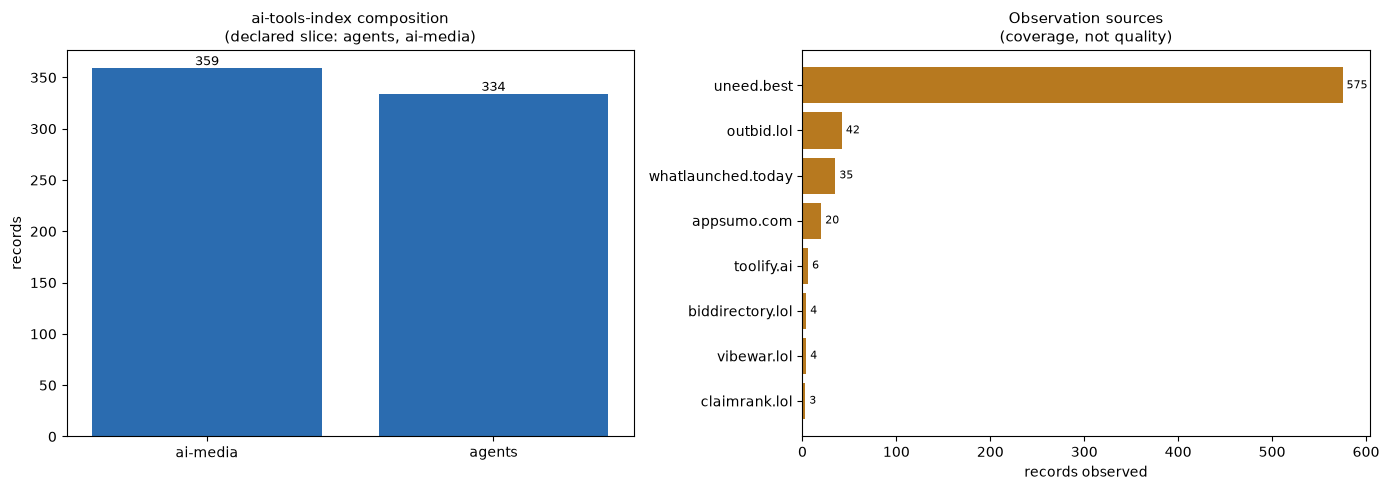

In [7]:
top_sources = sources.head(8).iloc[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(actual["category"], actual["records"], color="#2b6cb0")
axes[0].set_ylabel("records")
axes[0].set_title(f"ai-tools-index composition\n(declared slice: {', '.join(declared)})", fontsize=11)
for bar, v in zip(bars, actual["records"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v, f"{int(v)}",
                 ha="center", va="bottom", fontsize=9)

axes[1].barh(top_sources["discovered_from"], top_sources["recordCount"], color="#b7791f")
axes[1].set_xlabel("records observed")
axes[1].set_title("Observation sources\n(coverage, not quality)", fontsize=11)
for y, v in enumerate(top_sources["recordCount"]):
    axes[1].text(v, y, f" {int(v)}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## Findings

In [8]:
top_source = sources.iloc[0]
low_conf = int((aitools["category_confidence"] <= 0.5).sum())

findings = [
    f"The ai-tools-index covers {coverage['records']:,} records across "
    f"{coverage['distinctDomains']:,} distinct domains.",

    f"Its declared slice is {declared}, and the records match that declaration "
    f"exactly ({len(off_slice)} records outside the slice). It is therefore an "
    "agents + AI-media slice, not a general AI tools census.",

    f"Composition: " + "; ".join(
        f"{r.category} = {int(r.records)} ({r.sharePct}%)" for r in actual.itertuples()
    ) + ".",

    f"{coverage['onRankBoard']:,} of {coverage['records']:,} records "
    f"({coverage['onRankBoardPct']}%) appear on the Harpd Rank board.",

    f"Records come from {coverage['distinctDiscoverySources']} sources; "
    f"'{top_source['discovered_from']}' accounts for {int(top_source['recordCount']):,} "
    f"({top_source['sharePct']}%).",

    f"{len(shared):,} of the {len(agent_domains):,} agent-slice domains "
    f"({len(shared)/len(agent_domains)*100:.2f}%) also appear in this slice, which "
    "follows directly from the overlapping slice definitions.",

    f"Category confidence at or below 0.5: {low_conf:,} of {coverage['records']:,} "
    f"({low_conf/coverage['records']*100:.2f}%).",

    "This slice is a coverage view, not a ranking, and no product is ordered by quality.",
]

for i, line in enumerate(findings, 1):
    print(f"{i}. {line}")

1. The ai-tools-index covers 693 records across 693 distinct domains.
2. Its declared slice is ['agents', 'ai-media'], and the records match that declaration exactly (0 records outside the slice). It is therefore an agents + AI-media slice, not a general AI tools census.
3. Composition: ai-media = 359 (51.8%); agents = 334 (48.2%).
4. 0 of 693 records (0.0%) appear on the Harpd Rank board.
5. Records come from 12 sources; 'uneed.best' accounts for 575 (82.97%).
6. 334 of the 334 agent-slice domains (100.00%) also appear in this slice, which follows directly from the overlapping slice definitions.
7. Category confidence at or below 0.5: 384 of 693 (55.41%).
8. This slice is a coverage view, not a ranking, and no product is ordered by quality.


## Limitations

- **Coverage, not ranking.** Nothing here measures product quality or adoption.
- The filename `ai-tools-index` is broader than its contents. The slice is
  `agents + ai-media` only, so it must not be cited as "all AI tools".
- The overlap with `ai-agent-index` is an artefact of the slice definitions and
  should not be read as a substantive finding about the market.
- One discovery source dominates, so the slice reflects that source's coverage.
- Category assignment is automated and low-confidence for a large share of records.
- No usage, revenue or traffic metric is present, and none is estimated.
- A single observation window means no trend can be measured.
- Domain-level overlap cannot detect the same product under two different domains,
  so all overlap counts are lower bounds.


## Reproducibility

In [9]:
import platform
import sys

print("Reproduce this notebook")
print("=" * 60)
print("python :", sys.version.split()[0], "on", platform.platform())
print("pandas :", pd.__version__)
print("data   :", loader.resolved_data_base())
print()
print("From a clean machine:")
print("  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks")
print("  cd harpd-ai-research-notebooks")
print("  python -m venv .venv && . .venv/bin/activate")
print("  pip install -r requirements.txt")
print("  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>")
print()
print("Offline / pinned snapshot:")
print("  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...")


Reproduce this notebook
python : 3.13.12 on macOS-26.6.2-arm64-arm-64bit-Mach-O
pandas : 3.0.5
data   : https://raw.githubusercontent.com/harpd-dev/harpd-ai-datasets/main/

From a clean machine:
  git clone https://github.com/harpd-dev/harpd-ai-research-notebooks
  cd harpd-ai-research-notebooks
  python -m venv .venv && . .venv/bin/activate
  pip install -r requirements.txt
  jupyter nbconvert --to notebook --execute --inplace notebooks/<this file>

Offline / pinned snapshot:
  HARPD_DATA_BASE=/path/to/harpd-ai-datasets/ jupyter nbconvert ...


## Sources

- Dataset registry: <https://github.com/harpd-dev/harpd-ai-datasets>
- Canonical data home: <https://harpd.com/data/>
- File: `data/research/ai-tools-index.json`
- Comparison files: `data/research/ai-agent-index.json`, `data/research/developer-tools-index.json`
- Licence: CC BY 4.0

**Licence.** All Harpd dataset content is published under CC BY 4.0.

**Attribution.** Harpd (<https://harpd.com>).

**Not a source for.** Product quality, traffic, revenue, review scores or
market size. None of those are measured by these datasets, and none are
estimated in this notebook.
